In [1]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib as mpl
import anafibre as fib
from anafibre.plotting import animate_fields_xy, add_visible_spectrum, plot_dispersion_chart, plot_dispersion_vs_wavelength
import astropy.units as u
import astropy.constants as co
from scipy.constants import epsilon_0 as eps0, mu_0 as mu0
plt.rcParams['text.usetex'] = True
from IPython.display import HTML

In [2]:
SiO2  = fib.RefractiveIndexMaterial(shelf='glass', book='fused_silica', page='Malitson')
H2O   = fib.RefractiveIndexMaterial(shelf='main', book='H2O', page='Hale')

In [ ]:
wl=674*u.nm
n_fibre=SiO2.get_refractive_index(wl.value)
n_mesh=H2O.get_refractive_index(wl.value)

In [16]:
# This script sets up a step-index fibre with specific parameters.
fibre = fib.StepIndexFibre(
    core_radius = 250*u.nm, 
    eps_core = n_fibre**2,    
    eps_clad = n_mesh**2,    
    mu_core  = 1,    
    mu_clad  = 1   
) 
display(n_fibre, n_mesh)

array(1.45591128)

array(1.331)

In [32]:
print(format(n_fibre, '.15e'))
print(format(n_mesh, '.15e'))

1.455911278952111e+00
1.331000000000000e+00


In [11]:
mode0 = fibre.HE(ell=1, n=1, wl=wl, a_plus=1, a_minus=1)
mode1 = fibre.HE(ell=1, n=1, wl=wl, a_plus=1, a_minus=-1)
# mode2 = fibre.TE(n=1, wl=wl)
# mode3 = fibre.TM(n=1, wl=wl)
# mode4 = fibre.HE(ell=2, n=1, wl=wl, a_plus=1, a_minus=1)
# mode5 = fibre.HE(ell=2, n=1, wl=wl, a_plus=1, a_minus=-1)
fib.display_modes(mode0, mode1)#, mode2, mode3, mode4, mode5)


Mode,λ [nm],V,ne,s1,s2,s3
HE11,674.00,1.38,1.3505,1.00,0.00,0.00
HE11,674.00,1.38,1.3505,-1.00,-0.00,0.00


In [30]:
print(format(mode1.kz, '.15e'))

1.258999476319380e+07


In [28]:
print("{:.17g}".format(mode1.kz))

12589994.763193797


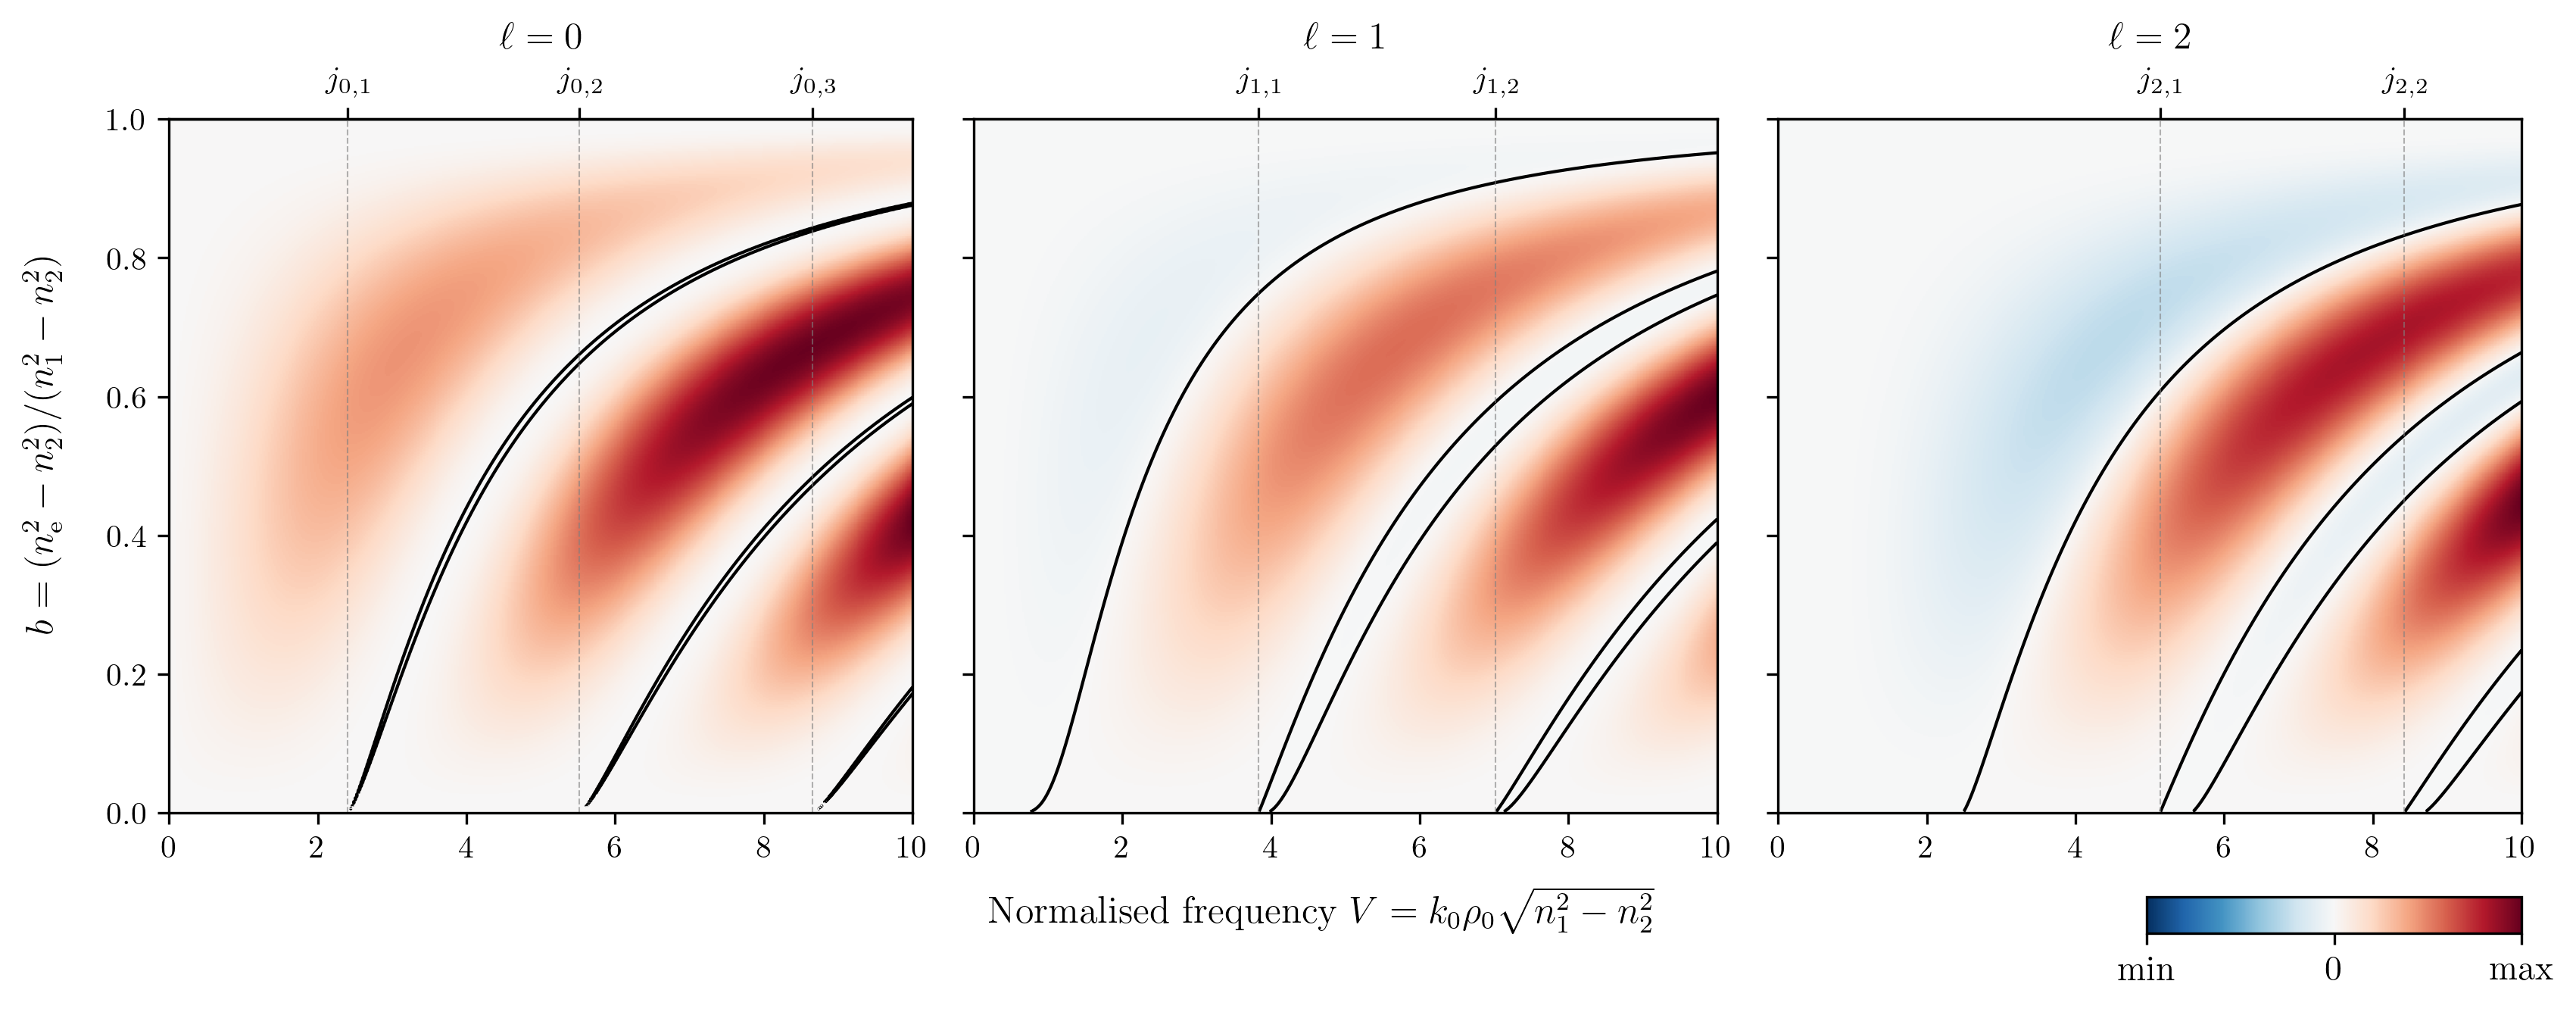

In [7]:
import matplotlib as mpl
# mpl.use("pgf")
mpl.rcParams.update({
    "font.family": "serif",
    "text.usetex": True,
})
# plt.rcParams.update({
#     "font.size": 14,          # base font size
#     "axes.titlesize": 16,     # subplot titles
#     "axes.labelsize": 16,     # axis labels
#     "xtick.labelsize": 13,
#     "ytick.labelsize": 13,
#     "legend.fontsize": 13,
# })
fig, axes = plt.subplots(1, 3, figsize=(11, 4), sharey=True, dpi=300)
ells = [0, 1, 2]
for i, (ax, ell) in enumerate(zip(axes, ells)):
    plot_dispersion_chart(
        fibre, ell=ell, ax=ax,
        ylabel=False,     
        xlabel=False,
        # Vmin=0
    )
    ax.set_title(rf"$\ell = {ell}$")
fig.supxlabel(r"Normalised frequency $V=k_0\rho_0\sqrt{n_1^2 - n_2^2}$", y=-0.04)
fig.supylabel(r"$b = (n_\mathrm{e}^2-n_2^2)/(n_1^2-n_2^2)$", x=-0.02)

# Create a dummy ScalarMappable from -1 to 1, colormap as in your plot
dummy_norm = mpl.colors.Normalize(vmin=-1, vmax=1)
dummy_sm = mpl.cm.ScalarMappable(norm=dummy_norm, cmap='RdBu_r')

# Place the colorbar wherever you want; tweak [left, bottom, width, height]
cbar_ax = fig.add_axes([.83, -0.04, 0.15, 0.04])  # Adjust as needed!

cb = fig.colorbar(dummy_sm, cax=cbar_ax, orientation='horizontal')
cb.set_ticks([-1, 0, 1])
cb.set_ticklabels(['min', '0', 'max'])
cb.ax.tick_params(labelsize=11)

# plt.tight_layout()
# plt.show()
# plt.savefig("dispersion.pdf", bbox_inches="tight", dpi=300)

In [ ]:
anim = animate_fields_xy(modes=[mode0, mode1],weights=[1,1],scale=15)
HTML(anim.to_jshtml())